---
title: "Thinning/Lifting E-Graphs: Checkpoint I"
date: 2026-04-18
---

Thinnings are something that shows up when you think about binders and contexts. I've been trying to build an alpha equivalence aware e-graph using the concept. For a moment complexity seemed spiralling out of control, but actually as I understand what is going on, I'm throwing out more and more code and things are getting simpler. I am overdue for checkpoint.

- https://www.philipzucker.com/thin_hash_cons_codebruijn/
- https://www.philipzucker.com/thin_monus_uf/
- https://www.philipzucker.com/thin1/



# Lifting: Functions Aren't Constants
The recent way I've been thinking about them is as functional lifting combinators. When you say "context" or use a turnstile, it's a bit mysterious and kind of syntactic feeling. However, that you can lift a function $\sin :  \mathbb{R} \rightarrow \mathbb{R}$ into a higher dimensional version.

There is the 1-d version of sine we all know and love

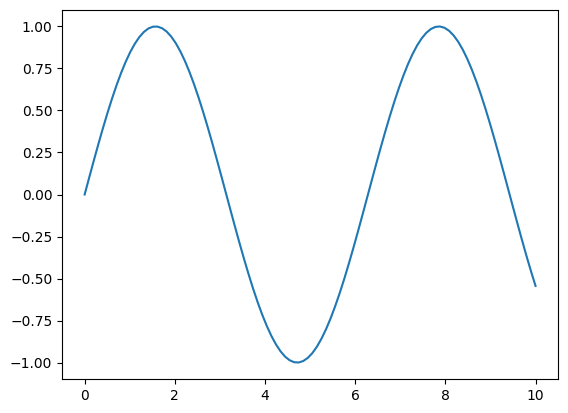

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
xs = np.linspace(0,10,100)
plt.plot(xs, np.sin(xs))

I can write a simple combinator that describes how to lift a function to take higher arguments parametrized by a thinning.

In [ ]:
type Thin = list[bool]
def lift(t : Thin, f):
    return lambda *args: f(*[arg for take, arg in zip(t,args) if take])

And then there are two simple ways to lift it into a function that takes in 2D arguments. These plots are different, the functions are different, and yet they are all _kind of_ "sine".

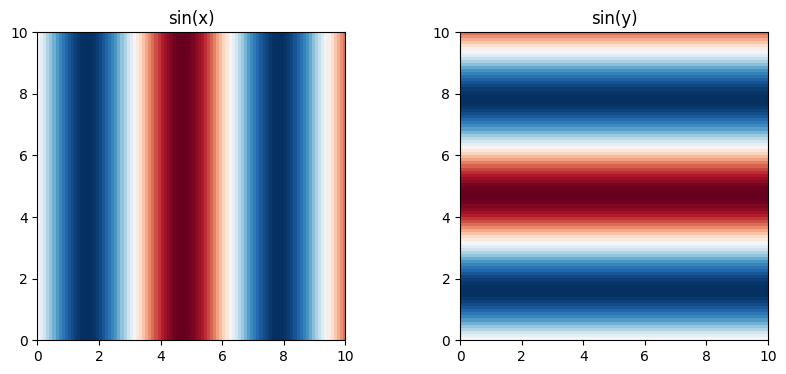

In [ ]:
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)

X, Y = np.meshgrid(x, y)

sinx = lift([True,False], np.sin)(X,Y) #np.sin(X)   # (x,y) -> sin(x)
siny = lift([False,True], np.sin)(X,Y) #np.sin(Y)   # (x,y) -> sin(y)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(sinx, extent=[x.min(), x.max(), y.min(), y.max()],
              origin="lower", cmap="RdBu")
axs[0].set_title("sin(x)")
axs[1].imshow(siny, extent=[x.min(), x.max(), y.min(), y.max()],
              origin="lower", cmap="RdBu")
axs[1].set_title("sin(y)")
plt.show()


You can use this same sort of this to get a handle on the coordinates themselves by lifting identity functions

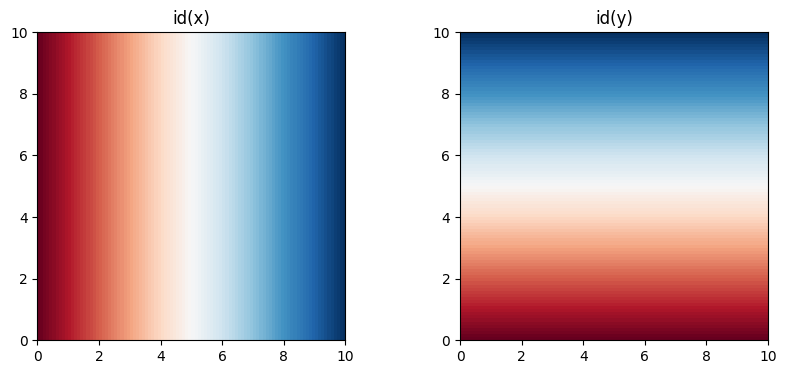

In [ ]:
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)

X, Y = np.meshgrid(x, y)

id = lambda x: x

idx = lift([True,False], id)(X,Y) #np.sin(X)   # (x,y) -> sin(x)
idy = lift([False,True], id)(X,Y) #np.sin(Y)   # (x,y) -> sin(y)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(idx, extent=[x.min(), x.max(), y.min(), y.max()],
              origin="lower", cmap="RdBu")
axs[0].set_title("id(x)")
axs[1].imshow(idy, extent=[x.min(), x.max(), y.min(), y.max()],
              origin="lower", cmap="RdBu")
axs[1].set_title("id(y)")
plt.show()

You also can lift constants into functions. Constants and functions that always return the same constant are NOT the same. But they are related.

In [ ]:
def const(x): # 0-arity function that return x
    return lambda: x

Trying to apply const to 17 is a type error

In [ ]:
const(42)(17)

TypeError: const.<locals>.<lambda>() takes 0 positional arguments but 1 was given

But if you lift it first now it works

In [ ]:
lift([False], const(42))(17)

42

I'm drawing these pictures and writing this running code to show that what I'm talking about isn't just meangingless syntax manipulations. We're talking about a simple manipulation of actual mathematical objects. It is these manipulations that the thinning e-graph is trying to bake in because it is a ubiquitous phenomenon to lift low dimensional stuff into higher dimensional stuff. That is kind of what happens semantically every time you bind a new variable.

# Thinning E-Graph

Ok, so anyway, let's put the two hemispheres of uranium together to make the thinning e-graph. As a little experiment, I'm switching over to rust. The working file is here https://github.com/philzook58/microeggpy/blob/main/src/thin.rs

There are some more functions or different angles on functions on thinnings since last time. 

#### meet
The thing I was previously calling the "least common multiple" before I now am calling the "widest common thinning" or perhaps just the "meet". It is the bitwise and. "Division" was a strange operation and it kind of makes sense to have these operations just output the divisions at the same time, sine I immediately need them.

I have some sense there is category theory lurking in the background. The meet is probably a pullback square.

The meet is needed when two eids are unioned with differing minimal contexts needed. This is a confusing point to me still. The slotted e-graph has this subtle trick where unexpectedly the "free variables" or "slots" of two differing terms combine by their _intersection_ not the _union_ of their publics slots. Upon deeper inspection of the semantics of slotted e-graphs, I think this is because the public slots is _not_ the free variables that might be inside the terms, but instead something like the free variables inside the term set that it is not symmettric with respect to. The intersection actually makes sense because it a super mega renaming closure move. More on this some other day if Rudi and I ever finish that slotted blog post.

Here I think my best interpretation is that the union find isn't exactly actually expressing "eqaulity" but instead a particular notion of refinement. Enumerating the enodes in the "eclass" gives you an index of enodes you might be able to refine into, depending on how many variables you currently have in your context.

#### join
The join was needed in the smart constructor for `app`. When you create an enode with two children, they need to start reconciled into the same context. `app` should also make sure that you work in a minimal context so that you don't make redundant enodes. Any variable that is used by neither should not be part of the interned enode. The join is the bitwise or, so it describes the variables used by both.

I think I could encode the workings of the thinning e-graph into a regular e-graph and more regular smart constructor. The move that is happening here is that you should push all `lift(thin, t)` out as far as possible using moves like `f(lift(thin, t)) --> lift(thin1(f(lift(thin2, t))))` such that `thin1 . thin2 = thin` and that the domain of `thin2` is as small as possible. This is trying to put the ubiquitous `lift` operations into a normal form, as one might for AC symbols etc. For binary operations `f(lift(thina, a), lift(thinb, b)) --> lift(thin1(f(lift(thina1, a), lift(thinb1, b))))` you need to look at `thina` and `thinb` and kind of compromise between them for how much you can actually pull out.

Each `f` is in some sense a size polymorphic version? For example `sin` isn't really the `R -> R` version, it is the `sin' = comp sin : (R^n -> R) -> (R^n -> R)` version. This is evocative of Yoneda like manipulations.

#### commuting triangles
A big surprise to me was the seeming need for this operation.

If you have two edges of a triangle   `nodectx2 ---> minctx <----- nodectx2`, you could ask for an arrow `nodectx1 ---> nodectx2` to complete the triangle into a commuting one. For thinnings, this arrow (if it exists) is not necessarily unique. It is all the ways of thinning one nodectx into the other while keeping all the common variables in minctx fixed.

I'm still figuring out how exactly to make sense of the e-matching operation.


In [ ]:
use std::collections::HashMap;
use std::fmt::Debug;
use std::iter::zip;
#[derive(Clone, Debug, Eq, Hash, PartialEq)]
pub struct Thin(Vec<bool>); // TODO: swtich to bitvec. smallbitvec, or smallvec, u32, box_leak;
// Is there a lighter weight thing if it doesn't need to be resizable? Neh.

impl Thin {
    //! Thinnings are mappings between contexts represented as bitvectors. true means keep, false means drop.
    //! They can also be thought of as liftings of functions by adding unused arguments
    //! [x,y,z].thin([true,false,true]) => [x,z]
    //! [x,z].widen([true,false,true]) => [x,_,z]
    //! https://www.philipzucker.com/thin1/
    pub fn id(n: usize) -> Self {
        Thin(vec![true; n])
    }

    pub fn is_id(&self) -> bool {
        self.0.iter().all(|b| *b)
    }

    /// Thinning go from big to small
    pub fn dom(&self) -> usize {
        self.0.len()
    }

    pub fn cod(&self) -> usize {
        self.0.iter().filter(|i| **i).count()
    }

    fn dump0(&self) -> Self {
        //! Dump the first variable in the context. Useful for lambda abstraction where lambdas create a variable in scope
        let mut thin = self.0.clone();
        thin.remove(0);
        Thin(thin)
    }

    pub fn comp(&self, small: &Thin) -> Thin {
        //! compose self with small. self : A -> B, small : B -> C, output : A -> C
        assert_eq!(self.cod(), small.dom());
        let mut res = Vec::with_capacity(self.0.len());
        let mut j = 0;
        for b in self.0.iter() {
            if *b {
                res.push(small.0[j]);
                j += 1;
            } else {
                res.push(false);
            }
        }
        Thin(res)
    }

    //pub fn comp_mut(&mut self, other : &Thin){
    //}

    pub fn meet(&self, other: &Thin) -> (Thin, Thin, Thin) {
        //! widest_common_subthinning
        //! meet
        //! Compute the bitwise and widest common thinning and how to get there.
        //! self.comp(out.1) = other.comp(out.2)
        //! Pullback?
        debug_assert_eq!(self.dom(), other.dom());
        // Should I just do the dumb loop?
        let mut common = Vec::with_capacity(self.dom());
        let mut proj_self = vec![];
        let mut proj_other = vec![];
        for (&a, &b) in zip(self.0.iter(), other.0.iter()) {
            common.push(a && b);
            if a {
                proj_self.push(b);
            }
            if b {
                proj_other.push(a);
            }
        }
        (Thin(common), Thin(proj_self), Thin(proj_other))
    }

    pub fn join(&self, other: &Thin) -> (Thin, Thin, Thin) {
        //! thinnest_common_superthinning
        //! join
        //! union
        //! bitwise or
        // pushout?
        // common prefix
        debug_assert_eq!(self.dom(), other.dom());
        let mut prefix = Vec::with_capacity(self.dom());
        let mut proj_self = vec![];
        let mut proj_other = vec![];
        for (&a, &b) in zip(self.0.iter(), other.0.iter()) {
            prefix.push(a || b);
            if a || b {
                proj_self.push(a);
                proj_other.push(b);
            }
        }
        (Thin(prefix), Thin(proj_self), Thin(proj_other))
    }

    fn is_ge(&self, other: &Thin) -> bool {
        //! Is self a subthinning of other? I.e. is there a thinning from self to other?
        //! Proof relevant version would return the thinning that does it. Does there exists t, such that self . t = other
        debug_assert_eq!(self.dom(), other.dom());
        zip(self.0.iter(), other.0.iter()).all(|(a, b)| !*a || *b)
    }

    fn all_comm_triangles(&self, other: &Thin) -> Vec<Thin> {
        debug_assert_eq!(self.cod(), other.cod());
        if self.dom() <= other.dom() {
            if self == other {
                return vec![self.clone()];
            } else {
                return vec![];
            }
        }
        // tuple of how far along in other and current prefix
        let mut partials = vec![(0, Vec::with_capacity(self.dom()))];
        for &target in &self.0 {
            let mut next = Vec::new();
            for (j, bits) in partials {
                if !target {
                    let mut skip = bits.clone();
                    skip.push(false);
                    next.push((j, skip));
                }

                if j < other.dom() && other.0[j] == target {
                    let mut take = bits;
                    take.push(true);
                    next.push((j + 1, take));
                }
            }
            partials = next;
        }

        let res = partials
            .into_iter()
            .filter_map(|(j, bits)| (j == other.dom()).then_some(Thin(bits)))
            .collect::<Vec<_>>();
        debug_assert!(res.iter().all(|t| t.comp(other) == *self));
        res
    }
}

I have ended up choosing to go with a binary application style rather than typically n-ary application style terms. It has some cute properties. One is that I don't need a seperate string interning mechanism. Function symbols are just constants like everything else. This enables lambda free higher order reasoning to and partial application. Writing ematching over binary App is also nice and it doesn't require there to be a `Vec` for arguments in the node.

On the downside, there is more lookup, you don't get all the children at once. It is also not really the most boring standard notion of Term.

Some smart constructors make constructing terms a little  more pleasant. I also have some macros for it, which are maybe a good idea maybe bad.

I think tossing out the lambda constructor for now is a huge win. Alpha equivalence and lambda are not the same thing. There is a simpler thing that still has a notion of alpha and context without internalizing the context as a lambda. Let us understand that deeply first.

In [ ]:
/// An ordinary syntax tree for user readability. Using the raw api is very painful and error prone.
#[derive(PartialEq, Eq, Hash, Clone, Debug)]
pub enum Term {
    Var(String),
    App(Box<Term>, Box<Term>),
    //Lam(String, Box<Term>),
    Lit(String),
    EId(Id), // Do I want Vec<String> here? Or does the Id narrow from the full context. But I might not even know
             // PVar(String, Vec<String>) Miller pattern var
             // Drop(String, Box<Term>) explicitly say a variable is dropped. For weakening to an Id? Or for weakening to pattern variable, which then always captures everything
             // Kind of the converse of Lam.
}

impl Term {
    pub fn var(v: &str) -> Self {
        Term::Var(v.to_string())
    }
    pub fn app(f: Term, x: Term) -> Self {
        Term::App(Box::new(f), Box::new(x))
    }
    pub fn app2(f: Term, x: Term, y: Term) -> Self {
        Term::App(Box::new(Term::App(Box::new(f), Box::new(x))), Box::new(y))
    }
    pub fn app3(f: Term, x: Term, y: Term, z: Term) -> Self {
        Term::App(
            Box::new(Term::App(
                Box::new(Term::App(Box::new(f), Box::new(x))),
                Box::new(y),
            )),
            Box::new(z),
        )
    }
    pub fn lit(s: &str) -> Self {
        Term::Lit(s.to_string())
    }
}
type TermInCtx = (Vec<String>, Term);


I ended up going with an aegraph UNode style. This choice seems correlated with the need to produce new identifiers on union and have enodes uniquely have integer indentifiers. I need to put _something_ into `nodes` to keep it in sync with `uf`.

At first I thought it was necessary, since the sibling linked list style eclass enumeration could be structured in the correct way to track the thinnings. But now I think this is redundant data, since you can access the thinnings through find anyway?

An interesting (and necessary?) aspect of this approach and slotted's is that there is only one variable enode. It represents in some sense the identity function in a single variable context, and all other variables in larger ocntexts are just thinnings/liftings of this one.

Originally I had a `Lam` constructor, and I'll put it back in when things have stabilized, but I find it interesting the whole thing still makes perfect sense without out. My point has often been that I'm working on binders and alpha, not lambda and beta persay.

I think a bespoke substitution routine is possibly in the cards. I am worried that somehow it will not be able to be made to work.

In [ ]:
#[derive(Clone, Debug, Eq, Hash, PartialEq)]
enum Node {
    App(Id, Id),
    Var,
    Lit(String), 
    UNode(Id, Id), // Maybe rawid because everything in eclass has same minimal context. No. rawid are terms which have a very concrete
}

#[derive(Clone, Debug, Eq, PartialEq)]
pub struct EGraph {
    memo: HashMap<Node, Id>,
    nodes: Vec<Node>,
    uf: Vec<Id>,
    minctx: Vec<usize>, // Not sure if necessary?
}
pub fn varid() -> Id {
    Id(Thin::id(1), 0)
}

type UserId = (Vec<String>, Id);

impl EGraph {
    pub fn new() -> Self {
        let mut memo = HashMap::new();
        memo.insert(Node::Var, varid());
        EGraph {
            memo,
            nodes: vec![Node::Var],
            uf: vec![varid()],
            minctx: vec![1],
        }
    }

    fn add_node(&mut self, ctx: usize, n: Node) -> Id {
        if let Some(id) = self.memo.get(&n) {
            self.find(id)
        } else {
            let id = Id(Thin::id(ctx), self.uf.len());
            self.uf.push(id.clone());
            self.nodes.push(n.clone());
            self.memo.insert(n, id.clone());
            self.minctx.push(ctx);
            id
        }
    }

    pub fn app(&mut self, f: Id, x: Id) -> Id {
        assert!(f.ctx() == x.ctx());
        let f = self.find(&f);
        let x = self.find(&x);
        // Construct the app in the smallest common needed context
        let (common, f1thin, x1thin) = f.0.join(&x.0);
        let id = self.add_node(common.cod(), Node::App(Id(f1thin, f.1), Id(x1thin, x.1)));
        // Lift back into context actually requested
        id.weaken(&common)

    }


    pub fn var(&self) -> Id {
        varid()
    }

    pub fn lit(&mut self, s: String) -> Id {
        self.add_node(0, Node::Lit(s))
    }

    pub fn find(&self, id: &Id) -> Id {
        let Id(mut thin, mut rawid) = id.clone();
        loop {
            let Id(thin1, rawid1) = self.uf[rawid].clone();
            if rawid1 == rawid {
                assert!(thin1.is_id());
                return Id(thin, rawid);
            } else {
                thin = thin.comp(&thin1);
                rawid = rawid1;
            }
        }
    }

    pub fn named_find(&self, nid: &UserId) -> UserId {
        let id = self.find(&nid.1);
        (named::apply_thin(&id.0, &nid.0), id)
    }
    pub fn is_eq(&mut self, a: &Id, b: &Id) -> bool {
        self.find(a) == self.find(b)
    }

    fn union(&mut self, a: &Id, b: &Id) -> bool {
        assert_eq!(a.ctx(), b.ctx(), "Can only union ids in the same context");
        let a = self.find(a);
        let b = self.find(b);
        if a == b {
            false
        }
        // TODO: We can avoid making a new rawid in many cases (?) But unodes?
        else {
            let (common, proj_a, proj_b) = Thin::meet(&a.0, &b.0);
            let Id(_, rawz) = self.add_node(
                common.cod(),
                Node::UNode(Id(proj_a.clone(), a.1), Id(proj_b.clone(), b.1)),
            );
            self.uf[a.1] = Id(proj_a, rawz);
            self.uf[b.1] = Id(proj_b, rawz);
            true
        }
    }

    pub fn rebuild(&mut self) {
        loop {
            let mut done = true;
            for i in 0..self.nodes.len() {
                let node = &self.nodes[i];
                let id = self.find(&self.uf[i]);
                match node {
                    Node::Lit(_) => {}
                    Node::Var => {}
                    Node::UNode(_, _) => {}
                    Node::App(f, x) => {
                        let id1 = self.app(f.clone(), x.clone());
                        done &= !self.union(&id, &id1);
                    }
                }
            }
            if done {
                return;
            }
        }
    }

Adding terms is kind of interesting. Manual entry of thinned terms is not for humans to do.

I think I've gone through a couple iterations of this realizing that work I'm doing here oculd be somewhere else or is redundant.


In [ ]:
    pub fn add_term(&mut self, ctx: &[String], t: &Term) -> Id {
        match t {
            Term::App(f, x) => {
                let f = self.add_term(ctx, f);
                let x = self.add_term(ctx, x);
                self.app(f, x)
            }
            Term::Lit(l) => {
                let t = Thin(vec![false; ctx.len()]);
                self.lit(l.clone()).weaken(&t)
            }
            Term::Var(x) => {
                let idx = ctx.iter().position(|y| y == x).unwrap();
                let mut t = vec![false; ctx.len()];
                t[idx] = true;
                varid().weaken(&Thin(t))
            }
            Term::EId(eid) => eid.clone(),
        }
    }

# E matching
E-matching I think will make sense. It needs to be searching over all the ways a thinning could make sense. This corresponds to searching over how unconstrained variables may be the same as variables in other spots of the term. The big place where there happens is in stuff like `x*0=0`. In more typical situations, this isn't even a problem.

In [ ]:
    // I maybe suspect this should just be what happens when you hit a unode in ematching.

    fn all_liftable_node_ids(&self, id0: &Id) -> Vec<Id> {
        /*
        We find to rawid with smallest minctx and seek out all rawids that can be lifted into the requested context
        We then ave to reconcile all the ways there other thing may have to be fit into the larger context
        */
        let id0 = self.find(id0);
        let mut res = vec![];
        let ctx = id0.ctx();
        let thin0 = id0.0;
        let mut todo = vec![Id(Thin::id(thin0.cod()), id0.1)];
        while let Some(Id(thin, rawid)) = todo.pop() {
            match &self.nodes[rawid] {
                Node::UNode(a, b) => {
                    if a.ctx() <= ctx {
                        todo.push(Id(a.0.comp(&thin), a.1)); // This composition is in the opposite direction of weakening
                    }
                    if b.ctx() <= ctx {
                        todo.push(Id(b.0.comp(&thin), b.1));
                    }
                }
                _ => res.extend(
                    thin0
                        .all_comm_triangles(&thin)
                        .into_iter()
                        .map(|thin1| Id(thin1, rawid)),
                ),
            }
        }
        res
    }

    fn ematch(&self, pat: &Term, id: &Id) -> Vec<()> {
        let res = vec![];
        for id1 in self.all_liftable_node_ids(id) {
            let node = &self.nodes[id1.1];
            match (pat, node) {
                (Term::App(f, x), Node::App(f1, x1)) => {}
                //(Term::Lam(v, body), Node::Lam { var_used, rawid }) => {}
                (Term::Lit(l), Node::Lit(l1)) => {}
                (Term::Var(v), Node::Var) => {}
                (_, _) => {} // Term::EId(id1), _ =>
            }
        }
        res
    }


## Bits and Bobbles

Notation for lifting terms. I have tried different notations `{x,y |-> sin(x)}` `[x,y] |- sin(x)`, `{2 |-> sin(v1)}` but they are very confusing. The fully context annotated form is very verbose as a term. I also would like a crisper understand of the thinning rewrite rules considered as a more ordinary first order rewrite system.


Max has pushed back on the concept of structured / fat eids. EIds shouldn't be fat. The point of them is to be maximally lightweight things. Shouldn't the data go elsewhere? In a group union find, why can't you just have group action enodes and a constant propagation rule (specially built in or as just a regular rule) `act(g1, act(g2, X)) -> act(g1 * g2, X)` where `*` is a built in function. This does leave behind some junk `act` nodes, but maybe you could also clean those up. 

One story I kind of like about this is comparing it to garbage collection. The enode arena is basically a bump allocator. If you manually delete enodes, you're kind of doing maually memory management with `free` and all the perils thereof. Copying an entire egraph into a new one with junk compacted away is like a copying garbage collector. One could note certain enodes as keep or not keep with a boolean field. The keep enodes are the ones that are being used as a termbank whereas the non-keep enodes (ephemeral enodes) are only there because a keep enode needs them. In this scheme, you could have



I submitted a talk proposal to EGRAPHS 2026 on it. We'll see. 
I think as a member of the program committee, it makes sense to give a proposal from me less weight. People in this community have heard me talk anyway. Also the work as it stans is pretty unfinished. I like that the EGRAPHS call for proposals says "ongoing work". I feel like that takes the pressure off.
I am uncomfortable that the work isn't quite at the spot I'd like right now, but I feel like I can have it in the right spot by the time egraphs actually rolls around. I would like to share it and I think if I wait til next year, I'll have something else I'm running hot on by then.
I also like that it is open author and not double blind or whatever. Sometimes I feel like worrying about that in inhibiting to talking about work while it's hot and interesting to you. Saying things multiple times is _good_ and saying it while you're working on it is _good_.
I'm been on a micro lull in posting because I visited California to see my new niece Romy. Also trying to get thinning egraphs working. I've also been trying to use more rust, which is less familiar to me, more verbose, and also despite evxcr_jupyter not that amenable to my fast and loose scratchpad workflow. Still, it's a skill I want and it feels good to be building a base of technology in a way that isn't kneecapped at the outset performance ceiling and shippability wise. 
I wish ocaml had a better way to make libraries for other languages.

This version I still think is redundant. I don't think returning the UserId in the minimal context is necessary. I should just return the context asked for. And in that case, maybe don't return UserId at all? I'm still pretty shaky on how ematching is going to pass something sensible between the left hand and right hand side.

In [ ]:
type Thin = list[bool]
def dom(f : Thin): # domain is big side
    return len(f)
def cod(f : Thin): # codomain is small side
    return sum(f)
# The action on contexts and terms
# f(t)    widens t
# (ctx)f  thins a context
def comp(f : Thin, g : Thin) -> Thin:
    assert cod(f) == dom(g)
    i = 0 
    result = []
    for a in f:
        if a:
            result.append(g[i])
            i += 1
        else:
            result.append(False)
    assert i == len(g)
    return result   

def lcm(f : Thin, g : Thin) -> Thin:
    assert len(f) == len(g)
    return [a and b for a,b in zip(f,g)]

def div(f : Thin, g : Thin) -> Thin:
    assert dom(f) == dom(g)
    assert all(not a for a,b in zip(f,g) if not b) # f is thinner than g
    return [a for a,b in zip(f,g) if b]
# comp(div(lcm(f,g), g), g) == f

type Id = tuple[Thin, int]
@dataclass
class ThinUF:
    parents : list[Id] = field(default_factory=list)
    def makeset(self, scope : int) -> Id:
        i = len(self.parents)
        id = ([True]*scope, i)
        self.parents.append(id)
        return id
    def find(self, x : Id) -> Id:
        thin, xid = x
        while True:
            (thiny, yid) = self.parents[xid]
            if xid == yid:
                assert all(thiny)
                return (thin, xid)
            thin = comp(thiny, thin)
            xid = yid
    def union(self, x : Id, y : Id) -> Id | None:
        thinx, xid = self.find(x)
        thiny, yid = self.find(y)
        if xid != yid or thinx != thiny:
            thinz = lcm(thinx,thiny)
            (_, z) = self.makeset(cod(thinz))
            self.parents[xid] = (div(thinz,thinx), z)
            self.parents[yid] = (div(thinz,thiny), z)
            return (thinz, z)
        else:
            # hmm
            return None

type Thin = tuple[bool, ...]
type Id = tuple[Thin, int]

def widen(thin, x : Id) -> Id: # weaken
    return (comp(thin,x[0]), x[1])




Yea, the case of identity thinning will be very common.
Maybe it does make sense to maintain an arena if thinning annotations
and a separate public slots vector.
This makes it much more incremental from context free
Bake in their rules on construction.


If the cod of x and y match, then the pullback becomes an equalizer which is more specialized.

Does this construction work on an category annotation?

is_eq(x,y) -> z,px,py | None
looks up rather than asserts pullback exists
but do we need to be doing lca?



Confusion
Things is different contexts can "thin equal"

t1 -thin1> weakt1  = weakt2 <thin2- t2
These are the arguments to union.
But what do we really learn?

Do we learn that t1 is sensical in common context?


We define a tag z that lives in the common (bigger) context. But then finding can't make a canonical one of these. The arrows go the wrong way. There isn't a canonical weakening.

So Unodes should contain projections to the common

Do I need Id(widethin, ) since ids are actually thinned from their original.
Maybe if I lookup the native size of rawid, I can tell by whether the thinning has a cod or dom of it.
Hmm. I need widenings?

Maybe the z is a marker saying (there is at least one term in this eclass that can work in this context)
No. Because 
[x] |- x*0
[y] |- y*0

Hmm. No but these are rename identical. The 0 |- 0 case doesn't work because 0 is great

[x] |- x * 0 = v0 * 0
[x,y] |- y * 0 = v1 * 0
Yes this is fine (if it even makes sense) because we have a stronger one.


1 |- v0 * 0


0 |- 0 





In [ ]:
# I just throw away te lcm itself
# and div has a weird precondition.
def widest_common_thinning(x : Thin, y : Thin) -> tuple[int, Thin, Thin]:
    assert dom(x) == dom(y)
    size = sum([a and b for a,b in zip(x,y)])
    proj_x = [b for a,b in zip(x,y) if a] # has dom == cod(x)
    proj_y = [a for a,b in zip(x,y) if b] # has dom == cod(y)
    return size, proj_x, proj_y

In [ ]:
@dataclass(frozen=True)
class App:
    f : Node
    x : Node


type Node = App | Lam | Var 

@dataclass
class EGraph:
    table : dict[Node,int] = field(default_factory=dict)
    nodes : list[Node] = field(default_factory=list)
    uf : ThinningUF = field(default_factory=ThinningUF)



lcm = thin to intersection. Common subseqeucne. common thinning
least common thinning
widest common thinning. wct

(f / g) . g = f


Ok, need to put the plutonium hemispheres together.



Thinnings form a tree-like partial order
https://en.wikipedia.org/wiki/Tree_(set_theory)
a proof relevant one. That's what let's us be kind of online about it

It's a forset of disconnnected thinning trees

Ok so we could have a subterm and a _path_ as the proof relevant connection.
subterms modulo theories though?
An observation/command chain as a path and sub-coterm?

Do in rust?




partial orders tree like
thinnings are a kind of bastracted subterm relationship
subterm union find.
destructor chains 

generalization of binary search for tree like orders

serial parallel partial order

destructor chains
If then else chains.
bdd context.
c1


In [ ]:
:dep bitvec

In [ ]:
use std::iter::zip;
#[derive(Clone, Debug, Eq, Hash, PartialEq)]
struct Thin (Vec<bool>);
// Is there a lighter weight thing if it doesn't need to be resiable? Neh.
impl Thin {

fn id(n : usize) -> Self {
    let mut v = Vec::with_capacity(n);
    for _ in 0..n{
        v.push(true);
    }
    Thin(v)
}

fn dom(&self) -> usize {
    self.0.len()
}

fn cod(&self) -> usize {
    self.0.iter().filter(|i| **i).count()
}


fn comp(&self, small : &Thin) -> Thin{
    assert!(self.cod() == small.dom());
    let mut res = Vec::with_capacity(self.0.len());
    let mut j = 0;
    for b in self.0.iter() {
        if *b {
            res.push(small.0[j]);
            j+=1;
        } else {
         res.push(false);   
        }
    }
    Thin(res)
}

fn lcm(&self, other : &Thin) -> Thin {
    assert!(self.dom() == other.dom());
    Thin(zip(self.0.iter(), other.0.iter()).map(|(x,y)| *x && *y).collect())
}

}






In [ ]:
assert!(Thin::id(3).dom() == 3);
assert!(Thin::id(3).cod() == 3);
let t1 = Thin(vec![true, false, true]);
assert!(&Thin::id(3).comp(&t1) == &t1);
assert!(&t1.comp(&Thin::id(2)) == &t1);



In [ ]:
use std::collections::HashMap;
#[derive(Clone, Debug, Eq, Hash, PartialEq)]
struct Id(Thin, usize);


#[derive(Clone, Debug, Eq, Hash, PartialEq)]
struct Node {
    f : String,
    args : Vec<Id>,
    extra : i8
}


#[derive(Clone, Debug,Eq,PartialEq, Default)]
struct ThinEGraph {
    memo : HashMap<Node, Id>,
    nodes : Vec<Node>,
    parents : Vec<Id>
}

impl ThinEGraph {
    fn add_node(&mut self, ctx : usize, node : Node) -> Id {
        if let Some(id) = self.memo.get(&node) {
            id.clone()
        }
        else {
            let id = Id(Thin::id(ctx), self.parents.len());
            self.parents.push(id.clone());
            self.memo.insert(node.clone(), id.clone());
            self.nodes.push(node);
            id
        }
    }
    fn app(&mut self, ctx : usize, f : String, args : Vec<Id>) -> Id {
        assert!(args.iter().all(|a| a.0.dom() == ctx));
        self.add_node(ctx, Node {f, args, extra:0})
    }
    fn lam(&mut self, body : Id) -> Id {
        self.add_node(body.0.dom() + 1, Node {f : "lam".to_string(), args: vec![body], extra:-1})
    }
    fn var(&mut self, idx : usize) -> Id {
        self.add_node(1, Node {f: "var".to_string(), args: vec![], extra: 1})
    }
    
}



How in the world is rewriting going to make any sense?
Any rule that has a binder in it is screwed?
foo(lam x, F(x)) ->  


In [ ]:
#[derive(Clone, Debug, Eq, Hash, PartialEq)]
enum Term {
    App(String,Vec<Term>),
    Var(String),
    Lam(String, Box<Term>),
    EId(Id)
}
type UserId = (Vec<String>, Id)

impl ThinEGraph {
    fn add_term(&mut self, maxctx : &[String], term : &Term) -> UserId {
        match term {
            Var(v) => (vec![v], self.var())
            Lam(v, body) => {
                let (mut ctx, bodyid) = self.add_term(&vec![v].extend(maxctx), body);
                if ctx[0] == v {
                    ctx.remove(0);
                    (ctx, self.lam(bodyid))
                }else{
                    (ctx, self.lam(bodyid))
                }
            }
            App(f, args) => {
                // reconcile args
                let uids = args.iter().map(|a| self.add_term(maxctx, a)).collect();
                
                let mut new_args = Vec::with_capacity(args.len());
                for a in args.iter() {
                    let (ctx, (thin, rawid)) = self.add_term(ctx, a);

                }



            }

        }

    }
}



Error: cannot find type `EGraph` in this scope

In [ ]:
impl EGraph {
    fn subst(&mut self, t : Id, v : usize, s : Id) {
        // recursively replace t[s/v]
        // v gets bumped around as you recurse. This is kind of like 
        fn worker()
    }
}

Error: cannot find type `EGraph` in this scope

If I can do egg lamda examples, we'll call that success.
Is named that bad really?


In [ ]:
(0..3).collect::<Vec<usize>>()

[0, 1, 2]

In [ ]:
    fn add_term_helper(&mut self, maxctx: &[String], t: Term) -> UserId {
        // Hmm. UserId could be a thinning from maxctx.
        match t {
            Term::Var(s) => (vec![s], self.var()), //  (maxctx.map(|name| name == s), self.var()
            Term::Lit(s) => (vec![], self.lit(s)),
            Term::App(f, x) => {
                let (fctx, fid) = self.add_term_helper(maxctx, *f);
                let (xctx, xid) = self.add_term_helper(maxctx, *x);
                let (minctx, widef, widex) = named::common_minctx(maxctx, &fctx, &xctx);
                // Hmm. What if add_node returns less than I thought? I should thin minctx
                (minctx, self.app(fid.weaken(&widef), xid.weaken(&widex)))
            }
            Term::EId(id) => {
                assert!(id.ctx() <= maxctx.len());
                //  = is_ssubseq(maxctx ,id.1).unwrap()
                (named::apply_thin(&id.0, maxctx), id)
            }
        }
    }

    pub fn add_term(&mut self, ctx: &[String], t: Term) -> UserId {
        // Make Result.
        let (minctx, id) = self.add_term_helper(ctx, t);
        let thin = named::is_subseq(ctx, &minctx).unwrap();
        (ctx.to_vec(), id.weaken(&thin))
    }
}